# Finding a dataset, reading it, and deciding whether it is any good

A short tour of one real dataset gathered by `terrastat`: **Eurostat's monthly poultry statistics**,
which run from January 1967 to 2026, so nearly sixty years of monthly data on hatcheries, chicks
and eggs across 39 countries.

Three things at once:

1. how to **find** a dataset among the thousands gathered,
2. how to **read** it, which means a short introduction to **Parquet**, the format everything is
   stored in,
3. how to judge whether it is **healthy enough to model**: how long the series are, how close to
   today they run, and how much is actually missing.

Nothing here needs the network. Run the cells top to bottom.

In [1]:
from pathlib import Path
import datetime as dt
import json

import polars as pl          # the library terrastat uses
import pandas as pd          # the one you probably already know
import pyarrow.parquet as pq # lets us inspect a Parquet file without reading it
import matplotlib.pyplot as plt

DATA = Path("../data")
if not DATA.exists():
    from terrastat.config import data_dir
    DATA = data_dir()

pl.Config.set_fmt_str_lengths(60)
TODAY = dt.date.today()
print("data directory:", DATA.resolve())

data directory: ./data


## 1. Finding a dataset

Each source has a catalogue: one row per dataset, with its title, size and frequencies, saved as a
Parquet file when the crawl first runs. Searching it is a plain string filter, and this is how you
would look for anything, not just poultry.

In [2]:
catalogue = pl.read_parquet(DATA / "catalog" / "eurostat.parquet").with_columns(
    pl.col("extra").str.json_path_match("$.type").alias("type"))

# which datasets have actually been downloaded so far?
fetched = {json.loads(l)["dataset_id"]
           for l in open(DATA / "state" / "eurostat.jsonl", encoding="utf-8")
           if l.strip() and json.loads(l)["status"] == "done"}

hits = (catalogue
        .filter((pl.col("type") == "dataset") & pl.col("title").str.contains("(?i)poultry|hen|egg"))
        .with_columns(pl.col("dataset_id").is_in(fetched).alias("fetched"))
        .sort("n_values", descending=True)
        .select("dataset_id", "title", "frequencies", "n_values", "fetched"))
print(f"{hits.height} datasets mention poultry, hens or eggs")
hits.head(8)

30 datasets mention poultry, hens or eggs


dataset_id,title,frequencies,n_values,fetched
str,str,list[str],i64,bool
"""ef_lsk_poultry""","""Poultry by NUTS 2 region""","[""A""]",2551141,true
"""ef_ah_poultry""","""Animal housing by type of poultry, utilised agricultural are…","[""A""]",2212344,true
"""apro_ec_poulm""","""Poultry - monthly data""","[""M""]",622764,true
"""isoc_ec_iprb""","""Problems encountered by individuals when buying/ordering ove…","[""A""]",496408,true
"""isoc_cisci_pb""","""Security related problems experienced when using the interne…","[""A""]",241772,true
"""ef_ah_poult""","""Outdoor access of poultry by type of animal housing, size cl…","[""A""]",173224,true
"""fish_aq2b""","""Production of fish eggs for human consumption from aquacultu…","[""A""]",120596,true
"""ef_ls_gvlayhen""","""Poultry: number of farms and heads by size of farm (UAA) and…","[""A""]",106661,true


`n_values` is the size Eurostat itself declares, so you can see how big something is before
downloading it. Note the `fetched` column: the crawl works smallest-first, so the largest datasets
are usually the ones still outstanding.

We will take `apro_ec_poulm`, the monthly one.

In [3]:
DATASET = "apro_ec_poulm"
observations = DATA / "datasets" / "eurostat" / DATASET / "observations.parquet"
metadata     = DATA / "datasets" / "eurostat" / DATASET / "dataset.json"
series_file  = DATA / "series"   / "eurostat" / "freq=M" / f"{DATASET}.parquet"

for f in (observations, metadata, series_file):
    print(f"{f.stat().st_size/1024:9.1f} KB  {f.name}")

   1126.7 KB  observations.parquet
      5.3 KB  dataset.json
    863.4 KB  apro_ec_poulm.parquet


## 2. What Parquet is, and looking before you load

If you have only used CSV, the useful idea is this: a CSV is a wall of text that you must read from
the top to learn anything about it, while a Parquet file is **columnar, typed and
self-describing**. It stores each column separately, records the types, and keeps a footer of
statistics.

That footer is why you can ask what is in a file without reading the data.

In [4]:
pf = pq.ParquetFile(observations)
print(f"rows       : {pf.metadata.num_rows:,}")
print(f"columns    : {pf.metadata.num_columns}")
print(f"row groups : {pf.metadata.num_row_groups}   (chunks that can be read independently)")
print()
print(pf.schema_arrow)

rows       : 691,287
columns    : 10
row groups : 1   (chunks that can be read independently)

series_key: large_string
freq: large_string
hatchitm: large_string
animals: large_string
unit: large_string
geo: large_string
period: large_string
date: date32[day]
value: double
flag: large_string


Notice the **types**: `date` is a real date and `value` a float. In a CSV both would be text and
every reader would guess, which is how a column of codes like `007` silently becomes the number 7.

## 3. Read it

This is *layer 1* of terrastat: one row per observation, the shape you want for tables, SQL and
plotting.

In [5]:
obs = pl.read_parquet(observations)
print(obs.shape)
obs.head()

(691287, 10)


series_key,freq,hatchitm,animals,unit,geo,period,date,value,flag
str,str,str,str,str,str,str,date,f64,str
"""M.CU.A5130M.THS.AT""","""M""","""CU""","""A5130M""","""THS""","""AT""","""1995-01""",1995-01-01,0.0,null
"""M.CU.A5130M.THS.AT""","""M""","""CU""","""A5130M""","""THS""","""AT""","""1995-02""",1995-02-01,0.0,null
"""M.CU.A5130M.THS.AT""","""M""","""CU""","""A5130M""","""THS""","""AT""","""1995-03""",1995-03-01,0.3,null
"""M.CU.A5130M.THS.AT""","""M""","""CU""","""A5130M""","""THS""","""AT""","""1995-04""",1995-04-01,0.0,null
"""M.CU.A5130M.THS.AT""","""M""","""CU""","""A5130M""","""THS""","""AT""","""1995-05""",1995-05-01,0.0,null


### The same thing in pandas

`pandas.read_parquet` reads the file directly; `.to_pandas()` converts a polars frame you already
have. The values match, but the dtypes differ slightly, which is worth seeing once: pandas reads a
Parquet date into `object`, while polars gives a proper `datetime64`.

In [6]:
obs_pd    = pd.read_parquet(observations)
obs_pd_pl = obs.to_pandas()
print("same values:", obs_pd.astype(str).equals(obs_pd_pl.astype(str)))
pd.DataFrame({"pandas.read_parquet": obs_pd.dtypes, "polars.to_pandas": obs_pd_pl.dtypes})

same values: True


,pandas.read_parquet,polars.to_pandas
series_key,str,str
freq,str,str
hatchitm,str,str
animals,str,str
unit,str,str
geo,str,str
period,str,str
date,object,datetime64[ms]
value,float64,float64
flag,str,str


In [7]:
# ask pandas for arrow-backed types and the dates come back as dates
pd.read_parquet(observations, dtype_backend="pyarrow").dtypes["date"]

date32[day][pyarrow]

## 4. Read only what you need

Because columns are stored separately, asking for two of them never touches the rest, and filters
skip whole row groups using the footer statistics. On a file this size it saves little; the same
two lines are what make a 50 GB file usable on a laptop.

In [8]:
pl.read_parquet(observations, columns=["date", "value"]).head(3)

date,value
date,f64
1995-01-01,0.0
1995-02-01,0.0
1995-03-01,0.3


In [9]:
# filter while reading; pyarrow pushes this down into the file
fr = pd.read_parquet(observations, filters=[("geo", "==", "FR")])
print(f"{len(fr):,} rows read, out of {pf.metadata.num_rows:,} in the file")
fr.head(3)

34,626 rows read, out of 691,287 in the file


,series_key,freq,hatchitm,animals,unit,geo,period,date,value,flag
0,M.CU.A5130M.THS.FR,M,CU,A5130M,THS,FR,1973-01,1973-01-01,1705.0,NaN
1,M.CU.A5130M.THS.FR,M,CU,A5130M,THS,FR,1973-02,1973-02-01,3041.0,NaN
2,M.CU.A5130M.THS.FR,M,CU,A5130M,THS,FR,1973-03,1973-03-01,5163.0,NaN


## 5. Codes, and what they mean

The table stores short codes rather than repeating "France" on every row, which is why it is small.
The meanings live beside it in `dataset.json`, with the licence and the citation the source asks
for.

In [10]:
meta = json.load(open(metadata, encoding="utf-8"))
print(meta["title"])
print("span    :", meta["time_start"], "->", meta["time_end"])
print("licence :", meta["license"]["id"])
print("cite as :", meta["license"]["attribution"][:100], "...")
print()
for d in meta["dimensions"]:
    print(f"{d['id']:9s} {d['name'][:42]:42s} {len(d['codes']):3d} codes")
    for c, label in list(d["codes"].items())[:3]:
        print(f"          {c:9s} {label}")

Poultry - monthly data
span    : 1967-01-01 -> 2026-07-01
licence : eurostat-reuse
cite as : Source: Eurostat, dataset apro_ec_poulm (Poultry - monthly data), https://ec.europa.eu/eurostat/data ...

freq      Time frequency                               1 codes
          M         Monthly
hatchitm  Activity of hatcheries                       8 codes
          CU        Chicks for use
          EPI       Eggs placed in incubation
          EXP       Exports
animals   Live animals                                10 codes
          A5130M    Chicks of mixed meat-laying breeds
          A5130O    Chicks of laying hen breeds (laying)
          A5130ON   Chicks of laying hen breeds (selection)
unit      Unit of measure                              1 codes
          THS       Thousand
geo       Geopolitical entity (reporting)             39 codes
          AT        Austria
          BA        Bosnia and Herzegovina
          BE        Belgium


In [11]:
labels = {d["id"]: d["codes"] for d in meta["dimensions"]}
(obs.with_columns(pl.col("geo").replace_strict(labels["geo"]).alias("country"),
                  pl.col("animals").replace_strict(labels["animals"]).alias("animal"))
    .select("country", "animal", "date", "value", "flag")
    .head(4))

country,animal,date,value,flag
str,str,date,f64,str
"""Austria""","""Chicks of mixed meat-laying breeds""",1995-01-01,0.0,null
"""Austria""","""Chicks of mixed meat-laying breeds""",1995-02-01,0.0,null
"""Austria""","""Chicks of mixed meat-laying breeds""",1995-03-01,0.3,null
"""Austria""","""Chicks of mixed meat-laying breeds""",1995-04-01,0.0,null


### The flags matter for modelling

A flag says *why* a number is what it is, or why it is absent. Eurostat packs two different things
into this column: the observation status (`p` provisional, `e` estimated, `b` a break in the
series) and, prefixed with `@`, the confidentiality status. `@C` means the value was suppressed as
confidential, so the row exists and the value is null on purpose.

In [12]:
flag_labels = {c: lab for a in meta["attributes"] for c, lab in a["codes"].items()}
(obs.group_by("flag").len().sort("len", descending=True)
    .with_columns(pl.col("flag").replace_strict(flag_labels, default="(no flag: a plain observation)").alias("meaning")))

flag,len,meaning
str,u32,str
null,545669,"""(no flag: a plain observation)"""
"""@C""",68523,"""confidential"""
"""p""",42943,"""provisional"""
"""e""",32159,"""estimated"""
"""n""",1930,"""not significant"""
"""b""",56,"""break in time series"""
"""u""",4,"""low reliability"""
"""be""",3,"""break in time series, estimated"""


## 6. One row per series, and a health check

terrastat also stores the same data with **one row per time series**, where the dates and values are
lists inside a single cell. Parquet handles nested types natively; CSV cannot express this at all.
This is the shape for modelling, and the shape to judge.

In [13]:
series = pl.read_parquet(series_file)
print(series.shape, "-> series x metadata columns")
series.select("series_uid", "geo_label", "units", "n_obs", "start_date", "end_date").head(4)

(2428, 36) -> series x metadata columns


series_uid,geo_label,units,n_obs,start_date,end_date
str,str,str,i64,date,date
"""eurostat:apro_ec_poulm:M.CU.A5130M.THS.AT""","""Austria""","""Thousand""",192,1995-01-01,2026-07-01
"""eurostat:apro_ec_poulm:M.CU.A5130M.THS.BA""","""Bosnia and Herzegovina""","""Thousand""",134,2014-01-01,2026-06-01
"""eurostat:apro_ec_poulm:M.CU.A5130M.THS.BE""","""Belgium""","""Thousand""",562,1973-01-01,2026-07-01
"""eurostat:apro_ec_poulm:M.CU.A5130M.THS.BG""","""Bulgaria""","""Thousand""",189,2006-01-01,2026-07-01


Now the question that actually decides whether you can use it. Four things matter:

- **length**: enough points to fit anything
- **recency**: does it run up to roughly today, or did it stop in 2014
- **completeness**: of the calendar between the first and last observation, how much is really there
- **flags**: how much is provisional, estimated or suppressed

There are two distinct kinds of hole, and they are worth keeping apart. A period can be *stored
with a null value*, because a flag explains it, or it can be *absent altogether*. The function
below measures both, and works on any dataset in the collection.

In [14]:
PERIOD_DAYS = {"D": 1, "W": 7, "BW": 14, "M": 30.44, "Q": 91.3, "S": 182.6, "A": 365.25}

def health(series: pl.DataFrame, today: dt.date = TODAY, min_len: int = 60) -> pl.DataFrame:
    # one row per check; works for any terrastat series file
    step = PERIOD_DAYS.get(series["frequency"][0], 30.44)
    d = series.with_columns(
        ((pl.lit(today) - pl.col("end_date")).dt.total_days() / step).alias("stale"),
        (pl.col("n_points") - pl.col("n_obs")).alias("null_rows"),
        (((pl.col("end_date") - pl.col("start_date")).dt.total_days() / step).round(0) + 1).alias("calendar"),
    ).with_columns((pl.col("n_obs") / pl.col("calendar")).alias("completeness"))
    n = d.height
    pct = lambda k: f"{k:,}  ({100*k/n:.0f}%)"
    checks = [
        ("series",                              f"{n:,}"),
        ("observations with a value",           f"{d['n_obs'].sum():,}"),
        ("length  min / median / max",          f"{d['n_obs'].min()} / {d['n_obs'].median():.0f} / {d['n_obs'].max()}"),
        (f"long enough (>= {min_len} points)",  pct(d.filter(pl.col("n_obs") >= min_len).height)),
        ("ends within 3 periods of today",      pct(d.filter(pl.col("stale") <= 3).height)),
        ("median staleness, in periods",        f"{d['stale'].median():.1f}"),
        ("complete calendar (>= 99%)",          pct(d.filter(pl.col("completeness") >= 0.99).height)),
        ("has periods stored but null",         pct(d.filter(pl.col("null_rows") > 0).height)),
        ("has periods missing entirely",        pct(d.filter(pl.col("calendar") > pl.col("n_points")).height)),
        ("values carrying a flag",              f"{d['n_flagged'].sum():,}  ({100*d['n_flagged'].sum()/max(1, d['n_points'].sum()):.0f}%)"),
    ]
    return pl.DataFrame({"check": [c for c, _ in checks], "value": [v for _, v in checks]})

health(series)

check,value
str,str
"""series""","""2,428"""
"""observations with a value""","""622,764"""
"""length min / median / max""","""1 / 200 / 715"""
"""long enough (>= 60 points)""","""2,134 (88%)"""
"""ends within 3 periods of today""","""1,141 (47%)"""
"""median staleness, in periods""","""3.3"""
"""complete calendar (>= 99%)""","""948 (39%)"""
"""has periods stored but null""","""616 (25%)"""
"""has periods missing entirely""","""1,465 (60%)"""


Read that as: the dataset is long and current, but only about a third of the series have a
complete calendar, and a fifth of all values carry a flag. That is normal for agricultural
statistics, where countries join late, stop reporting, or suppress figures for confidentiality.

So pick a working subset rather than using everything.

In [15]:
step = PERIOD_DAYS["M"]
stale = (pl.lit(TODAY) - pl.col("end_date")).dt.total_days() / step
usable = (series
          .with_columns((((pl.col("end_date") - pl.col("start_date")).dt.total_days()/step).round(0)+1).alias("calendar"))
          .with_columns((pl.col("n_obs")/pl.col("calendar")).alias("completeness"))
          .filter((pl.col("n_obs") >= 60) & (pl.col("completeness") >= 0.9) & (stale <= 6)))

print(f"usable: {usable.height:,} of {series.height:,} series "
      f"({100*usable.height/series.height:.0f}%) -- at least 60 points, 90% complete, under 6 months stale")
usable.select("geo_label", "n_obs", "start_date", "end_date").head(5)

usable: 1,112 of 2,428 series (46%) -- at least 60 points, 90% complete, under 6 months stale


geo_label,n_obs,start_date,end_date
str,i64,date,date
"""Spain""",464,1986-01-01,2026-07-01
"""Finland""",347,1997-09-01,2026-07-01
"""France""",643,1973-01-01,2026-07-01
"""Hungary""",307,2001-01-01,2026-07-01
"""Ireland""",585,1973-01-01,2026-06-01


## 7. Making a series human-readable

Every row already carries a `description`: the whole of the series' metadata written out as one
sentence, which is what a text encoder would be shown. It is built from the dimensions, so it is
unique to each series.

There is one catch worth knowing. For Eurostat and OECD the `title` column is the *dataset* title,
so all 2,428 series here share it; only FRED gives every series its own title. The distinctive
information lives in `dimensions`, a list of `{id, name, code, label}` per series.

In [16]:
print("title       :", series["title"][0])
print("distinct titles across the dataset:", series["title"].n_unique(), "for", series.height, "series")
print("distinct descriptions             :", series["description"].n_unique())
print()
for d in series["dimensions"][0]:
    print(f"  {d['id']:9s} {d['name'][:36]:36s} {d['code']:9s} {d['label']}")

title       : Poultry - monthly data
distinct titles across the dataset: 1 for 2428 series
distinct descriptions             : 2428

  freq      Time frequency                       M         Monthly
  hatchitm  Activity of hatcheries               CU        Chicks for use
  animals   Live animals                         A5130M    Chicks of mixed meat-laying breeds
  unit      Unit of measure                      THS       Thousand
  geo       Geopolitical entity (reporting)      AT        Austria


To build a name, you have to decide **which dimensions to include**, and that depends on where the
name will be seen.

Within this dataset, `freq` and `unit` are the same for every series, so repeating "Monthly,
Thousand" on all 2,428 of them tells a reader nothing they cannot see from the dataset title. Only
`hatchitm`, `animals` and `geo` distinguish one series from another.

But a constant dimension is **not uninformative** — it is only redundant *in this context*. The
moment a series leaves its dataset, which is exactly what happens in a training set mixing millions
of series from three sources, the unit is essential: `[18270.0, 17064.0, ...]` means nothing until
you know it is thousands of chicks per month. Here is how much that matters across Eurostat:

In [17]:
import glob, collections

const, unit_values = collections.Counter(), collections.Counter()
n_ds = 0
for p in glob.glob(str(DATA / "datasets" / "eurostat" / "*" / "dataset.json")):
    m = json.load(open(p, encoding="utf-8")); n_ds += 1
    for d in m.get("dimensions", []):
        if len(d["codes"]) == 1:                    # constant within its own dataset
            const[d["id"]] += 1
            if d["id"] == "unit":
                unit_values[next(iter(d["codes"].values()))] += 1

print(f"of {n_ds:,} Eurostat datasets, the dimension is constant in:")
for k, v in const.most_common(4):
    print(f"   {k:6s} {v:5,} datasets ({100*v/n_ds:.0f}%)")
print(f"\nyet `unit`, constant inside a dataset, still takes {len(unit_values)} different values across them:")
print("   " + " | ".join(f"{k} ({v:,})" for k, v in unit_values.most_common(6)))

of 6,652 Eurostat datasets, the dimension is constant in:
   freq   6,554 datasets (99%)
   unit   3,908 datasets (59%)
   geo      127 datasets (2%)
   indic_sb   106 datasets (2%)

yet `unit`, constant inside a dataset, still takes 135 different values across them:
   Percentage (1,436) | Number (890) | Thousand persons (351) | Person (158) | Thousand tonnes (124) | Thousand (115)


So the rule is: drop the constants when browsing **inside** one dataset, keep everything when the
series will be read **on its own**. The function below takes a `scope` argument for that, and
defaults to the safe one.

In [18]:
def varying_dimensions(series: pl.DataFrame) -> list[str]:
    # dimension ids that differ within this dataset
    seen: dict[str, set] = {}
    for dims in series["dimensions"].to_list():
        for d in dims or []:
            seen.setdefault(d["id"], set()).add(d["label"])
    return [i for i, labels in seen.items() if len(labels) > 1]


def label(row, varying=None, scope: str = "standalone") -> str:
    # scope='dataset'    drops dimensions constant within the dataset: shorter, for browsing it
    # scope='standalone' keeps them all: correct once the series is read outside its dataset
    dims = row["dimensions"] or []
    if scope == "dataset" and varying is not None:
        dims = [d for d in dims if d["id"] in varying]
    parts = [d["label"] for d in dims if d["label"]]
    return f"{row['title']} - {', '.join(parts)}" if parts else row["title"]


varying = varying_dimensions(series)
constant = [d["id"] for d in series["dimensions"][0] if d["id"] not in varying]
print("varies  :", varying)
print("constant:", constant)
print()
r = series.sort("n_obs", descending=True).row(1, named=True)
print("inside the dataset :", label(r, varying, scope="dataset"))
print("on its own         :", label(r, varying, scope="standalone"))

varies  : ['hatchitm', 'animals', 'geo']
constant: ['freq', 'unit']

inside the dataset : Poultry - monthly data - Chicks for use, Chicks of meat broiler breeds (fattening), France
on its own         : Poultry - monthly data - Monthly, Chicks for use, Chicks of meat broiler breeds (fattening), Thousand, France


Either way `description` is the field that never drops anything: it spells out every dimension with
its concept name, so it stays correct wherever the series ends up. That is why it, and not the
label, is what a text encoder should be given.

Now the three things you actually want to look at: **title, description, values**.

In [19]:
def readable(row, varying, n: int = 4) -> str:
    lines = [label(row, varying), "-" * 76, row["description"], ""]
    lines.append(f"{row['n_obs']} points, {row['start_date']} to {row['end_date']}, "
                 f"in {(row['units'] or 'unknown units').lower()}")
    lines.append(f"source: {'; '.join(row['origin_agencies'])}   licence: {row['license_id']}")
    pairs = [(d, v) for d, v in zip(row["dates"], row["values"]) if v is not None]
    lines.append("first : " + ",  ".join(f"{d} {v:,.0f}" for d, v in pairs[:n]))
    lines.append("last  : " + ",  ".join(f"{d} {v:,.0f}" for d, v in pairs[-n:]))
    return "\n".join(lines)


one = (usable.filter(pl.col("source_id").str.contains("A5130P") & (pl.col("geo") == "FR"))
             .sort("n_obs", descending=True).row(0, named=True))
print(readable(one, varying))

Poultry - monthly data - Monthly, Chicks for use, Chicks of meat broiler breeds (fattening), Thousand, France
----------------------------------------------------------------------------
Poultry - monthly data. Activity of hatcheries: Chicks for use. Live animals: Chicks of meat broiler breeds (fattening). Unit of measure: Thousand. Geopolitical entity (reporting): France. Frequency: Monthly.

715 points, 1967-01-01 to 2026-07-01, in thousand
source: Eurostat   licence: eurostat-reuse
first : 1967-01-01 18,270,  1967-02-01 17,064,  1967-03-01 20,874,  1967-04-01 19,923
last  : 2026-04-01 72,679,  2026-05-01 66,821,  2026-06-01 73,403,  2026-07-01 74,972


The same three fields as a table, when you want to scan many series at once.

In [20]:
readable_table = (series.sort("n_obs", descending=True).head(6)
    .with_columns(pl.struct(pl.all()).map_elements(lambda r: label(r, varying), return_dtype=pl.String).alias("label"))
    .select("label", "n_obs", "start_date", "end_date",
            pl.col("values").list.head(3).alias("first_values")))
readable_table

label,n_obs,start_date,end_date,first_values
str,i64,date,date,list[f64]
"""Poultry - monthly data - Monthly, Chicks for use, Chicks of …",715,1967-01-01,2026-07-01,"[2571.0, 3198.0, 4279.0]"
"""Poultry - monthly data - Monthly, Chicks for use, Chicks of …",715,1967-01-01,2026-07-01,"[18270.0, 17064.0, 20874.0]"
"""Poultry - monthly data - Monthly, Chicks for use, Chicks of …",714,1967-01-01,2026-06-01,"[260.0, 240.0, 232.0]"
"""Poultry - monthly data - Monthly, Eggs placed in incubation,…",714,1967-01-01,2026-06-01,"[525.0, 681.0, 960.0]"
"""Poultry - monthly data - Monthly, Chicks for use, Chicks of …",709,1967-01-01,2026-07-01,"[4137.5, 5808.0, 8801.5]"
"""Poultry - monthly data - Monthly, Eggs placed in incubation,…",708,1967-01-01,2026-05-01,"[4456.2, 6247.5, 7816.5]"


And as plain records, which is the shape to hand to a text model or write out as JSON.

In [21]:
def as_record(row, varying, keep: int | None = None) -> dict:
    vals = [v for v in row["values"] if v is not None]
    return {
        "title": label(row, varying),
        "description": row["description"],
        "units": row["units"],
        "frequency": row["frequency"],
        "start": str(row["start_date"]),
        "values": vals if keep is None else vals[:keep],
        "attribution": row["attribution"],
    }

rec = as_record(one, varying, keep=6)
print(json.dumps(rec, indent=2, ensure_ascii=False)[:700], "...")

{
  "title": "Poultry - monthly data - Monthly, Chicks for use, Chicks of meat broiler breeds (fattening), Thousand, France",
  "description": "Poultry - monthly data. Activity of hatcheries: Chicks for use. Live animals: Chicks of meat broiler breeds (fattening). Unit of measure: Thousand. Geopolitical entity (reporting): France. Frequency: Monthly.",
  "units": "Thousand",
  "frequency": "M",
  "start": "1967-01-01",
  "values": [
    18270.0,
    17064.0,
    20874.0,
    19923.0,
    19080.0,
    18079.0
  ],
  "attribution": "Source: Eurostat, dataset apro_ec_poulm (Poultry - monthly data), https://ec.europa.eu/eurostat/databrowser/view/apro_ec_poulm/default/table, accessed 2026-09-05"
 ...


## 8. Look at one

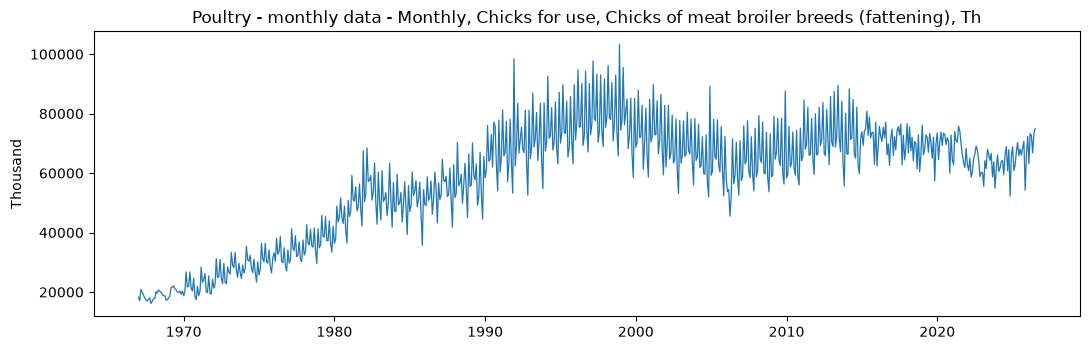

In [22]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(one["dates"], one["values"], linewidth=0.9)
ax.set_title(label(one, varying)[:95]); ax.set_ylabel(one["units"])
plt.tight_layout(); plt.show()

In [23]:
# lists survive the trip to pandas, as numpy arrays
row = series.to_pandas().query("series_uid == @one['series_uid']").iloc[0]
pd.Series(row["values"], index=pd.to_datetime(row["dates"]), name="chicks (thousands)").tail()

2026-03-01    73272.12
2026-04-01    72678.64
2026-05-01    66821.36
2026-06-01    73402.66
2026-07-01    74971.86
Name: chicks (thousands), dtype: float64

## 9. Why not just use CSV?

Measured on this very dataset rather than asserted.

In [24]:
import time, tempfile, os

tmp = Path(tempfile.gettempdir()) / "poultry.csv"
obs.write_csv(tmp)
t0 = time.perf_counter(); pl.read_csv(tmp);              t_csv = time.perf_counter() - t0
t0 = time.perf_counter(); pl.read_parquet(observations); t_pq  = time.perf_counter() - t0

print(f"{'':10s} {'size':>10s} {'read':>10s}")
print(f"{'CSV':10s} {os.path.getsize(tmp)/1e6:8.1f} MB {t_csv*1000:8.0f} ms")
print(f"{'Parquet':10s} {os.path.getsize(observations)/1e6:8.1f} MB {t_pq*1000:8.0f} ms")
print(f"\nParquet is {os.path.getsize(tmp)/os.path.getsize(observations):.0f}x smaller and "
      f"{t_csv/t_pq:.0f}x faster here, and it keeps the types the CSV threw away.")
tmp.unlink()

                 size       read
CSV            47.6 MB       45 ms
Parquet         1.2 MB       28 ms

Parquet is 41x smaller and 2x faster here, and it keeps the types the CSV threw away.


## 10. Cheat sheet

```python
# find a dataset
cat = pl.read_parquet("../data/catalog/eurostat.parquet")
cat.filter(pl.col("title").str.contains("(?i)poultry"))

# inspect a file without reading it
pq.ParquetFile(path).metadata        # rows, columns, row groups
pq.ParquetFile(path).schema_arrow    # names and types

# read
pl.read_parquet(path)                            # polars
pd.read_parquet(path, dtype_backend="pyarrow")   # pandas, with real dates

# read less
pl.read_parquet(path, columns=[...])
pd.read_parquet(path, filters=[("geo", "==", "FR")])
pl.scan_parquet(path).filter(...).collect()      # lazy: only touches what it needs

# many files as one table
pl.scan_parquet("../data/series/**/*.parquet").filter(pl.col("frequency") == "M").collect()

# write
df.write_parquet(path, compression="zstd")
```

Two habits worth keeping: use `scan_parquet` rather than `read_parquet` for anything large, so
filters happen inside the file instead of in memory afterwards; and when a folder of files shares a
schema, point a glob at the folder and treat it as one table instead of looping.

And one for the data itself: run the `health` check above before trusting a dataset. Length,
recency and completeness vary enormously between sources, and a series that stopped in 2014 looks
exactly like a current one until you ask.

Next: `getting_started.ipynb` covers the whole tool, all three sources, licensing, and how the
sharded snapshots for model training are built.